In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Exploratory Data Analysis

In [5]:
# Load the dataset
data = pd.read_csv("../../Step 1. Data Cleaning/Python code/outbreak_clean_v2.csv")

# View the data
data.head()

,year,month,date,season,state,state_abbr,primary_mode,setting,etiology,etiology_grouped,ifsac_category,food_vehicle,water_exposure,water_type,water_type_group,animal_type,animal_group,illnesses,hospitalizations,deaths,illnesses_std,hospitalizations_std,deaths_std,hosp_per_ill,death_per_ill,food_vehicle_missing,water_exposure_missing,is_food_related,is_water_related,is_animal_related
0,1971,2,1971-02-01,Winter,California,CA,Water,Restaurant,Copper,Other,Not Applicable,Not Applicable,Drinking water,Community,Drinking/Community Water,Not Applicable,Other/Unknown,2.0,0.0,0.0,-0.019976,-0.184611,-0.091011,0.0,0.0,Missing,Present,0,1,0
1,1971,6,1971-06-01,Summer,Arkansas,AR,Water,Store,Hepatitis A,Hepatitis,Not Applicable,Not Applicable,Drinking water,Other,Natural/Other,Not Applicable,Other/Unknown,98.0,0.0,0.0,0.041387,-0.184611,-0.091011,0.0,0.0,Missing,Present,0,1,0
2,1971,6,1971-06-01,Summer,Missouri,MO,Water,Subdivision/Neighborhood,Unknown,Unknown,Not Applicable,Not Applicable,Drinking water,Community,Drinking/Community Water,Not Applicable,Other/Unknown,2.0,0.0,0.0,-0.019976,-0.184611,-0.091011,0.0,0.0,Missing,Present,0,1,0
3,1971,6,1971-06-01,Summer,Alabama,AL,Water,Unknown,Selenium,Other,Not Applicable,Not Applicable,Drinking water,Individual/Private,Drinking/Community Water,Not Applicable,Other/Unknown,3.0,0.0,0.0,-0.019336,-0.184611,-0.091011,0.0,0.0,Missing,Present,0,1,0
4,1971,6,1971-06-01,Summer,Vermont,VT,Water,Community/municipality,Unknown,Unknown,Not Applicable,Not Applicable,Drinking water,Community,Drinking/Community Water,Not Applicable,Other/Unknown,3.0,0.0,0.0,-0.019336,-0.184611,-0.091011,0.0,0.0,Missing,Present,0,1,0


## Basic Dataset Overview

Check structure, missing data, and basic info.

In [9]:
# Dimensions and data types
print("Shape:", data.shape)
data.info()

Shape: (66706, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66706 entries, 0 to 66705
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    66706 non-null  int64  
 1   month                   66706 non-null  int64  
 2   date                    66706 non-null  object 
 3   season                  66706 non-null  object 
 4   state                   66706 non-null  object 
 5   state_abbr              66706 non-null  object 
 6   primary_mode            66706 non-null  object 
 7   setting                 66706 non-null  object 
 8   etiology                66706 non-null  object 
 9   etiology_grouped        66706 non-null  object 
 10  ifsac_category          66706 non-null  object 
 11  food_vehicle            66706 non-null  object 
 12  water_exposure          66706 non-null  object 
 13  water_type              66706 non-null  object 
 14  water_type_group   

In [10]:
# Summary statistics
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,66706.0,NaN,NaN,NaN,2012.698363,7.545193,1971.0,2009.0,2014.0,2018.0,2023.0
month,66706.0,NaN,NaN,NaN,5.691737,3.736758,1.0,2.0,5.0,9.0,12.0
date,66706,599,2017-01-01,798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,66706,4,Winter,24608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,66706,53,Wisconsin,3912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state_abbr,66706,53,WI,3912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_mode,66706,6,Person-to-person,32414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
setting,66706,597,Long-term care/nursing home/assisted living fa...,21224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
etiology,66706,787,Unknown,16763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
etiology_grouped,66706,8,Norovirus,33157,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Missing values
data.isna().sum().sort_values(ascending=False).head(20)

year                      0
month                     0
is_water_related          0
is_food_related           0
water_exposure_missing    0
food_vehicle_missing      0
death_per_ill             0
hosp_per_ill              0
deaths_std                0
hospitalizations_std      0
illnesses_std             0
deaths                    0
hospitalizations          0
illnesses                 0
animal_group              0
animal_type               0
water_type_group          0
water_type                0
water_exposure            0
food_vehicle              0
dtype: int64

## Data Composition

Explore variable types and unique values.

In [13]:
# Count categorical vs numeric
cat_cols = data.select_dtypes(include='object').columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numeric columns: {len(num_cols)}")

Categorical columns: 17
Numeric columns: 13


In [14]:
# Check unique values in categorical features
for col in cat_cols[:10]:
    print(f"{col}: {data[col].nunique()} unique values")

date: 599 unique values
season: 4 unique values
state: 53 unique values
state_abbr: 53 unique values
primary_mode: 6 unique values
setting: 597 unique values
etiology: 787 unique values
etiology_grouped: 8 unique values
ifsac_category: 26 unique values
food_vehicle: 3780 unique values


## Numeric Distributions

Explore distributions of illness-related variables

In [35]:
# Select numeric columns
numeric_cols = [
    'illnesses', 'hospitalizations', 'deaths',
    'illnesses_std', 'hospitalizations_std', 'deaths_std',
    'hosp_per_ill', 'death_per_ill'
]

# Summary statistics
data[numeric_cols].describe()

,illnesses,hospitalizations,deaths,illnesses_std,hospitalizations_std,deaths_std,hosp_per_ill,death_per_ill
count,66706.000000,66706.000000,66706.000000,6.670600e+04,6.670600e+04,6.670600e+04,66706.000000,66706.000000
mean,33.251477,0.718856,0.037253,3.451201e-17,6.423069e-17,2.620357e-17,0.053834,0.003056
std,1564.495083,3.893926,0.409329,1.000007e+00,1.000007e+00,1.000007e+00,0.166138,0.034310
min,2.000000,0.000000,0.000000,-1.997559e-02,-1.846109e-01,-9.101070e-02,0.000000,0.000000
25%,5.000000,0.000000,0.000000,-1.805802e-02,-1.846109e-01,-9.101070e-02,0.000000,0.000000
50%,14.000000,0.000000,0.000000,-1.230533e-02,-1.846109e-01,-9.101070e-02,0.000000,0.000000
75%,30.000000,0.000000,0.000000,-2.078307e-03,-1.846109e-01,-9.101070e-02,0.000000,0.000000
max,403000.000000,308.000000,50.000000,2.575718e+02,7.891352e+01,1.220611e+02,2.333333,1.000000


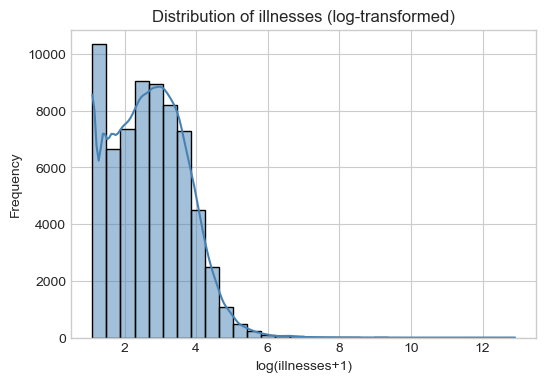

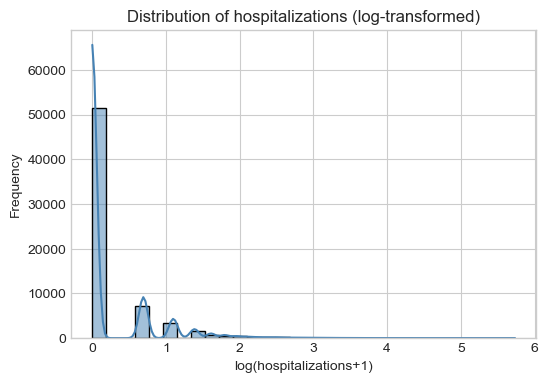

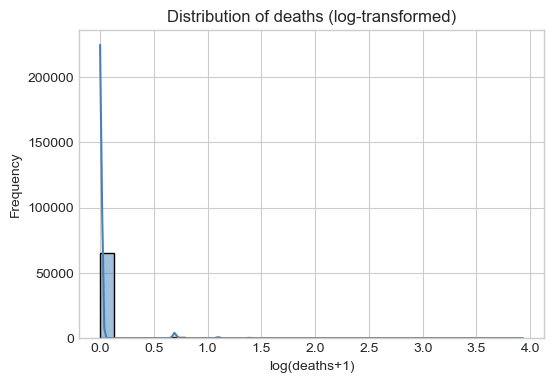

In [48]:
numeric_cols = ['illnesses', 'hospitalizations', 'deaths']

# Log-transform plots to handle skewness
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    # add 1 to avoid log(0)
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, color='steelblue')
    plt.title(f"Distribution of {col} (log-transformed)")
    plt.xlabel(f"log({col}+1)")
    plt.ylabel("Frequency")
    plt.show()

Interpretation:

- Most outbreaks are small, with few hospitalizations or deaths.
- Log scale reveals the shape of the bulk of the data without extreme outbreaks dominating the plot.
- There is a long tail of very large outbreaks for illnesses, which may represent epidemics or reporting anomalies.

## Seasonal or Yearly Trends

Show total illnesses per year to identify long-term patterns

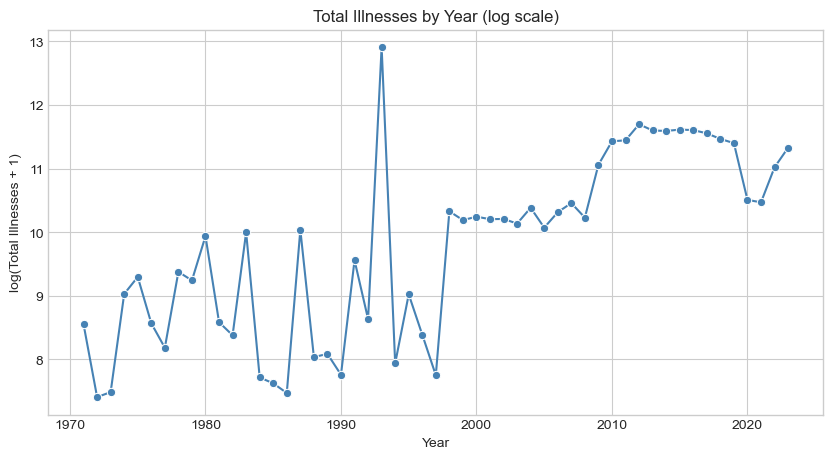

In [50]:
# Sum of illnesses per year (log scale)
yearly = data.groupby('year', as_index=False)['illnesses'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x='year', y=np.log1p(yearly['illnesses']), marker='o', color='steelblue')
plt.title("Total Illnesses by Year (log scale)")
plt.xlabel("Year")
plt.ylabel("log(Total Illnesses + 1)")
plt.show()

Interpretation:

- Log scale highlights yearly trends without being dominated by extreme outbreaks.
- Can reveal reporting improvements over time and identify peak years of large outbreaks.

Examine how outbreak severity changes by season

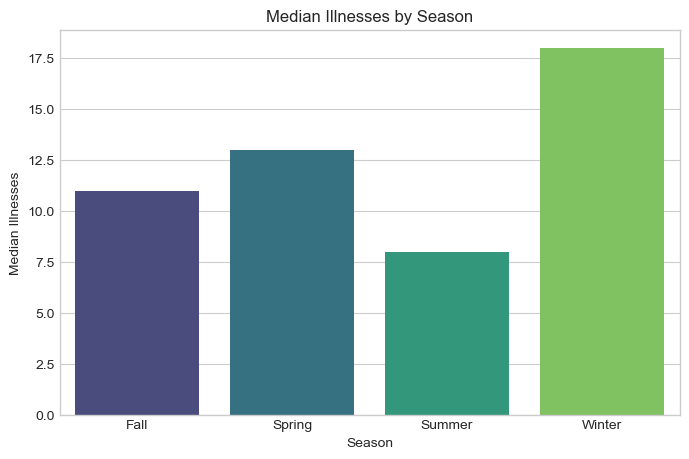

In [49]:
# Average illnesses by season
seasonal = data.groupby('season', as_index=False)['illnesses'].median()

plt.figure(figsize=(8,5))
sns.barplot(data=seasonal, x='season', y='illnesses', hue='season', 
            palette='viridis', legend=False)
plt.title("Median Illnesses by Season")
plt.xlabel("Season")
plt.ylabel("Median Illnesses")
plt.show()

Interpretation:

- Using median rather than mean avoids being skewed by rare, massive outbreaks.
- Seasonal trends can reveal higher baseline illnesses in certain seasons (e.g., summer/fall for foodborne outbreaks).

## Top Contributing Factors

Identify top 10 etiologies (causes) and settings contributing to outbreaks

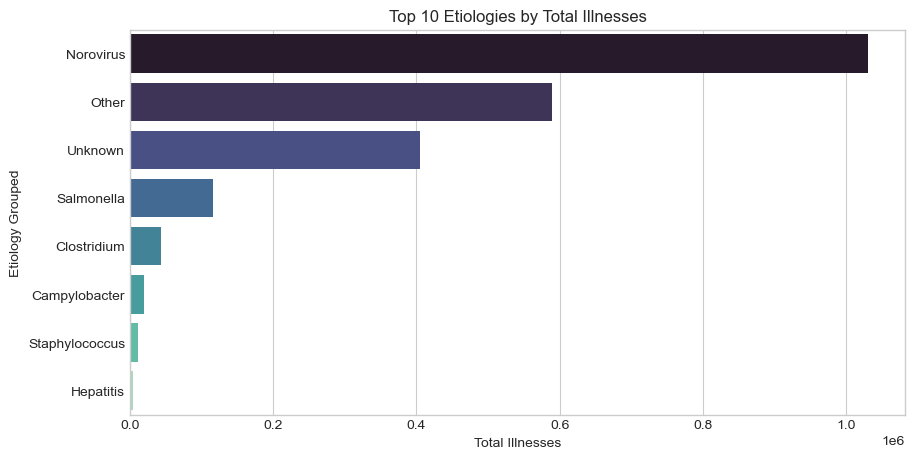

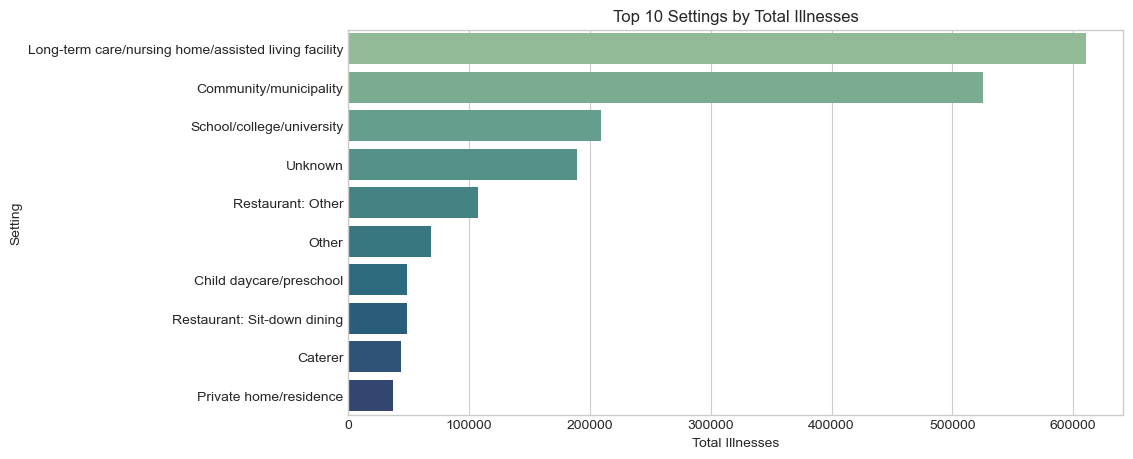

In [53]:
# Top 10 etiologies by total illnesses
top_etiology = data.groupby('etiology_grouped')['illnesses'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=top_etiology, y='etiology_grouped', x='illnesses', 
            hue='etiology_grouped', palette='mako', legend=False)
plt.title("Top 10 Etiologies by Total Illnesses")
plt.xlabel("Total Illnesses")
plt.ylabel("Etiology Grouped")
plt.show()

# Top 10 settings by total illnesses
top_setting = data.groupby('setting')['illnesses'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=top_setting, y='setting', x='illnesses', 
            hue='setting', palette='crest', legend=False)
plt.title("Top 10 Settings by Total Illnesses")
plt.xlabel("Total Illnesses")
plt.ylabel("Setting")
plt.show()

Interpretation:

- Highlights primary sources of outbreaks.
- Etiologies like Salmonella or Norovirus may dominate total illnesses.
- Settings like restaurants or long-term care facilities can explain outbreak clustering.
- Using total illnesses (or log scale if desired) shows which factors drive high-impact outbreaks.

## Severity Ratios

Compare median hospitalization and death ratios by etiology

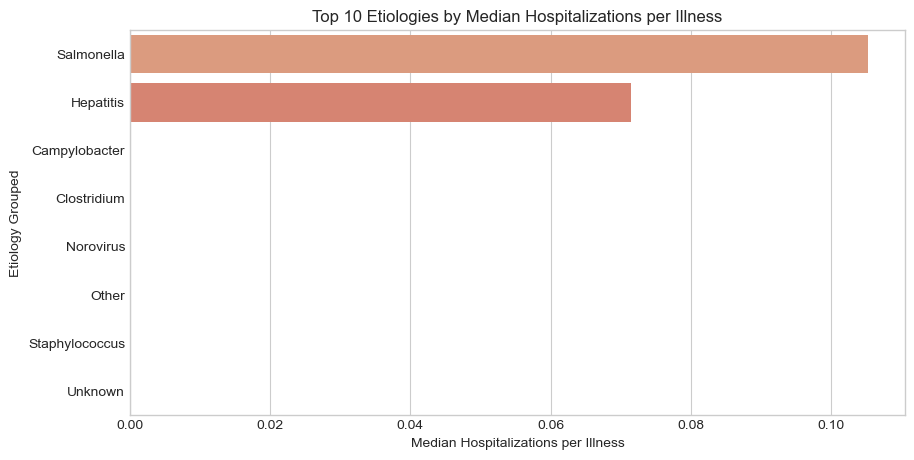

In [54]:
# Median severity ratios by etiology
severity = data.groupby('etiology_grouped', as_index=False)[['hosp_per_ill', 'death_per_ill']].median().sort_values(by='hosp_per_ill', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=severity, y='etiology_grouped', x='hosp_per_ill', 
            hue='etiology_grouped', palette='flare', legend=False)
plt.title("Top 10 Etiologies by Median Hospitalizations per Illness")
plt.xlabel("Median Hospitalizations per Illness")
plt.ylabel("Etiology Grouped")
plt.show()

Interpretation:

- Median ratios are more robust to extreme cases than the mean.
- Etiologies with higher hospitalization or death rates may indicate more severe infections, even if total outbreak counts are lower.

## Correlation Heatmap

Show relationships among numeric variables

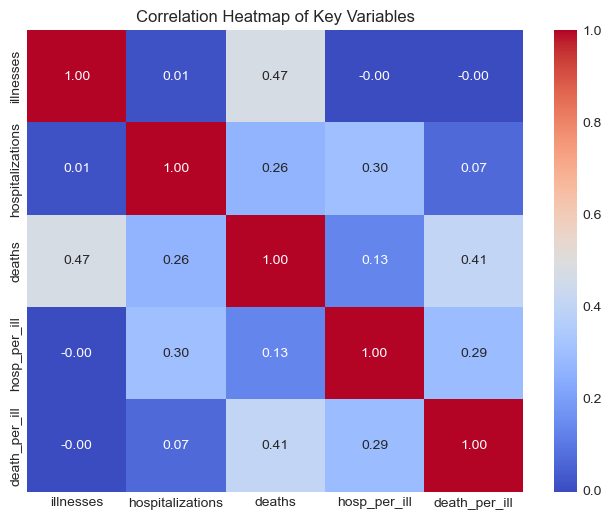

In [55]:
corr_cols = ['illnesses', 'hospitalizations', 'deaths', 'hosp_per_ill', 'death_per_ill']
plt.figure(figsize=(8,6))
sns.heatmap(data[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Key Variables")
plt.show()

Interpretation:

- Strong correlations can identify redundant or predictive features.
- Example: illnesses vs hospitalizations likely positively correlated; death_per_ill may be independent for most outbreaks.

## Geographic Trends

Visualize median illness counts by state

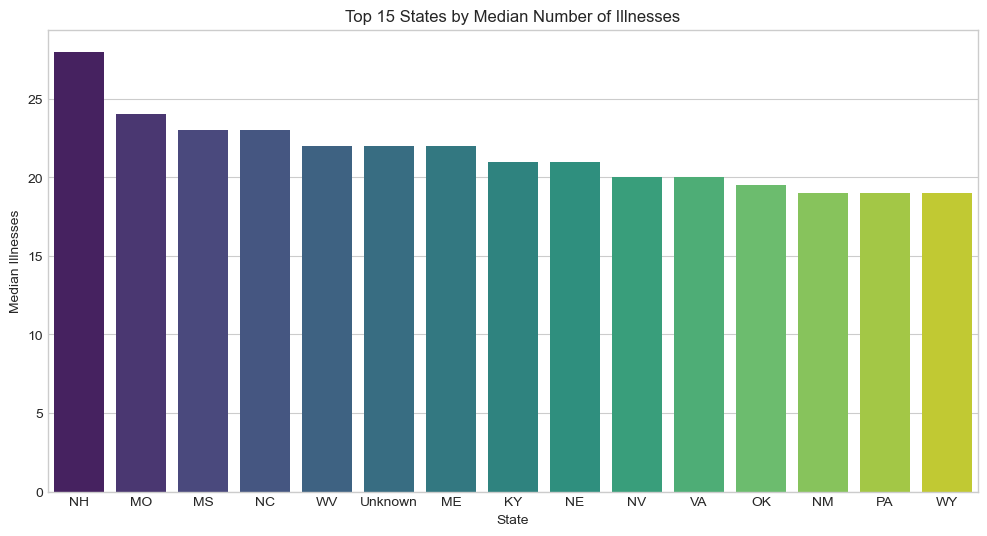

In [56]:
# Median illnesses by state to reduce skew
geo = data.groupby('state_abbr', as_index=False)['illnesses'].median()

plt.figure(figsize=(12,6))
sns.barplot(data=geo.sort_values('illnesses', ascending=False).head(15),
            x='state_abbr', y='illnesses', hue='state_abbr', palette='viridis', legend=False)
plt.title("Top 15 States by Median Number of Illnesses")
plt.xlabel("State")
plt.ylabel("Median Illnesses")
plt.show()

Interpretation:

- Median reduces impact of rare massive outbreaks.
- Reveals which states consistently report higher outbreak counts, possibly due to population size or reporting efficiency.